---

<h1 align="center">Assignment-5</h1>

---


### **Q1: Dataset Exploration**  

i. Load the dataset classification_dataset.csv using Pandas and display the first 10 rows.  

ii. Identify:  
a. Input attributes (features)  
b. Target variable (SpendingCategory)  

iii. Check the dataset for:  
a. Missing values  
b. Data types of attributes  
c. Distribution of the target variable  

In [1]:
# Cell 1: Import required libraries
import pandas as pd

In [18]:
# Cell 2: Load dataset and display first 10 rows
df = pd.read_csv("../../dataset/Mall_Customers.csv")
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [19]:
# Cell 3: Basic info
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns)

Shape of dataset: (200, 5)

Columns: Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [20]:
# Cell 4: Check missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [21]:
# Cell 5: Data types
print("Data Types:\n", df.dtypes)

Data Types:
 CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


### **Q2: Data Preprocessing**  

i. Convert categorical attributes (if any) into numerical form using Label Encoding.  

ii. Split the dataset into training (70%) and testing (30%) using scikit-learn.  

In [22]:
# Cell 6: Convert Spending Score into categories

def spending_category(score):
    if score <= 33:
        return "Low"
    elif score <= 66:
        return "Medium"
    else:
        return "High"

df["SpendingCategory"] = df["Spending Score (1-100)"].apply(spending_category)

# Cell 7: Check target distribution
print("Target Distribution:\n", df["SpendingCategory"].value_counts())

Target Distribution:
 SpendingCategory
Medium    94
High      57
Low       49
Name: count, dtype: int64


In [23]:
# Cell 8: Drop unnecessary columns
df.drop(["CustomerID", "Spending Score (1-100)"], axis=1, inplace=True)

In [28]:
# Cell 9: Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["SpendingCategory"] = le.fit_transform(df["SpendingCategory"])

In [29]:
# Cell 10: Define features and target
X = df.drop("SpendingCategory", axis=1)
y = df["SpendingCategory"]

In [30]:
# Cell 11: Train-test split (70-30)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### **Q3: Model Implementation**  

i. Train a Decision Tree classifier using the training dataset.  

ii. Use Gini Impurity as the splitting criterion and build the model.  

iii. Predict the class (SpendingCategory) for the test dataset.  


In [31]:
# Cell 12: Train Decision Tree (Gini)
from sklearn.tree import DecisionTreeClassifier

dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
dt_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [32]:
# Cell 13: Predictions
y_pred_gini = dt_gini.predict(X_test)

### **Q4: Model Evaluation**  

i. Evaluate the model using:  
a. Accuracy  
b. Confusion Matrix  

ii. Generate a classification report showing precision, recall, and F1-score.  

In [33]:
# Cell 14: Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy (Gini):", accuracy_score(y_test, y_pred_gini))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gini))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gini))

Accuracy (Gini): 0.7833333333333333

Confusion Matrix:
 [[12  1  1]
 [ 3 10  4]
 [ 2  2 25]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.86      0.77        14
           1       0.77      0.59      0.67        17
           2       0.83      0.86      0.85        29

    accuracy                           0.78        60
   macro avg       0.77      0.77      0.76        60
weighted avg       0.79      0.78      0.78        60



### **Q5: Tree Analysis**  

i. Visualize the trained decision tree and identify the root node feature.  

ii. Train another model using Entropy as the splitting criterion.  

iii. Compare the models built using Gini impurity and Entropy.  

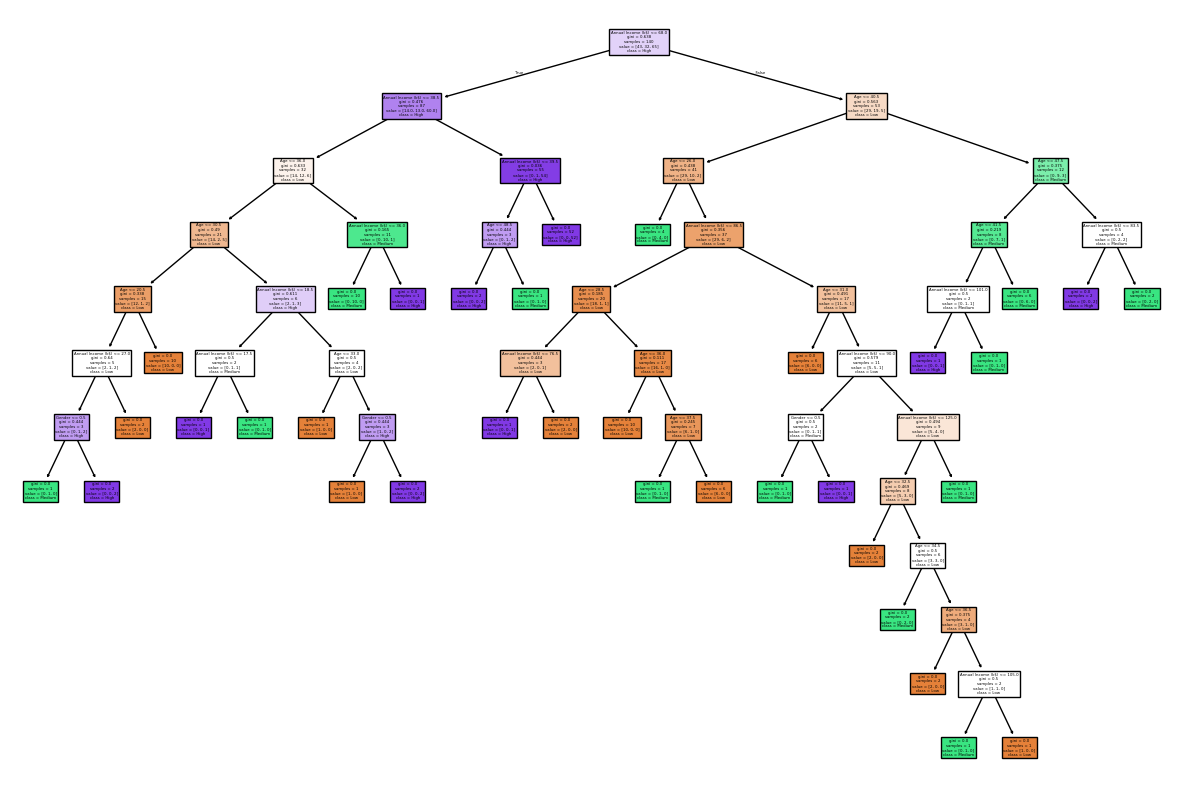

In [34]:
# Cell 15: Visualize Decision Tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(dt_gini, feature_names=X.columns, class_names=["Low", "Medium", "High"], filled=True)
plt.show()

In [35]:
# Cell 16: Root node feature
root_feature_index = dt_gini.tree_.feature[0]
print("Root Node Feature:", X.columns[root_feature_index])

Root Node Feature: Annual Income (k$)


### **Q3: Model Implementation - II** 

In [36]:
# Cell 17: Train Decision Tree (Entropy)
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [37]:
# Cell 18: Predictions (Entropy)
y_pred_entropy = dt_entropy.predict(X_test)

### **Q4: Model Evaluation - II**  

In [38]:
# Cell 19: Evaluation (Entropy)
print("Accuracy (Entropy):", accuracy_score(y_test, y_pred_entropy))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_entropy))
print("\nClassification Report:\n", classification_report(y_test, y_pred_entropy))

Accuracy (Entropy): 0.7

Confusion Matrix:
 [[10  2  2]
 [ 2  8  7]
 [ 3  2 24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.71      0.69        14
           1       0.67      0.47      0.55        17
           2       0.73      0.83      0.77        29

    accuracy                           0.70        60
   macro avg       0.69      0.67      0.67        60
weighted avg       0.70      0.70      0.69        60



### **Compare Models (Gini vs Entropy)** 

In [39]:
# Cell 20: Compare both models
print("Gini Accuracy:", accuracy_score(y_test, y_pred_gini))
print("Entropy Accuracy:", accuracy_score(y_test, y_pred_entropy))

Gini Accuracy: 0.7833333333333333
Entropy Accuracy: 0.7
